Cafe Sales Data Analysis Report

Data Preprocessing · PCA · EDA & Visualization


Project Overview

This report documents a full data analysis pipeline applied to a real-world cafe sales dataset (dirty_cafe_sales.csv) containing 10,000 transactions across 8 columns.

The pipeline covers three main stages:


Data Preprocessing — cleaning, imputation, and outlier handling
Dimensionality Reduction — Principal Component Analysis (PCA)
Exploratory Data Analysis — visualizations and pattern discovery

Step 1 — Import Libraries



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


Step 2 — Load the Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dirty_cafe_sales.csv to dirty_cafe_sales (1).csv


In [3]:
df = pd.read_csv("dirty_cafe_sales.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 8)

Columns: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']

Missing Values:
 Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

First 5 rows:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


Step 3 — Data Preprocessing

3.1 Replace Invalid String Values

In [4]:
df.replace(["ERROR", "UNKNOWN"], np.nan, inplace=True)

print("After replacing ERROR & UNKNOWN:")
print(df.isnull().sum())

After replacing ERROR & UNKNOWN:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


3.2 Convert Columns to Correct Data Types

In [5]:
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

print("Dtypes after conversion:")
print(df.dtypes)

Dtypes after conversion:
Transaction ID              object
Item                        object
Quantity                    object
Price Per Unit              object
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object


3.3 Remove Duplicate Rows

In [6]:
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Removed duplicates: {before - len(df)} rows")
print(f"Shape after: {df.shape}")

Removed duplicates: 0 rows
Shape after: (10000, 8)


3.4 Handle Missing Values

In [8]:
# convert all numeric columns first
num_cols = ["Quantity", "Price Per Unit", "Total Spent"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# numeric columns -> fill with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# categorical columns -> fill with mode
cat_cols = ["Item", "Payment Method", "Location"]
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# drop rows where date is missing
df.dropna(subset=["Transaction Date"], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nFinal shape: {df.shape}")

Missing values after cleaning:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Final shape: (9540, 8)


3.5 Handle Outliers (IQR Method)

In [9]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: {outliers} outliers fixed")

Quantity: 0 outliers fixed
Price Per Unit: 0 outliers fixed
Total Spent: 250 outliers fixed


Step 4 — Dimensionality Reduction (PCA)

4.1 Scale the Data



In [10]:
features = ["Quantity", "Price Per Unit", "Total Spent"]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")
print("Shape:", X_scaled.shape)

Data scaled successfully!
Shape: (9540, 3)


4.2 Analyze Variance per Component

In [11]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

for i, (var, cum) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1}: {var*100:.2f}%  |  Cumulative: {cum*100:.2f}%")

PC1: 63.66%  |  Cumulative: 63.66%
PC2: 33.21%  |  Cumulative: 96.87%
PC3: 3.13%  |  Cumulative: 100.00%


4.3 Apply Final PCA

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Location"] = df["Location"].values
df_pca["Payment Method"] = df["Payment Method"].values
df_pca["Item"] = df["Item"].values

print("PCA applied successfully!")
print(f"Reduced from {len(features)} features to 2 components")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

PCA applied successfully!
Reduced from 3 features to 2 components
Variance retained: 96.87%


Step 5 — Visualizations

5.1 Style Configuration

In [13]:
BG_DARK = "#0D1117"
BG_CARD = "#161B22"
TEXT_CLR = "#E6EDF3"
GRID_CLR = "#30363D"
PALETTE = ["#4361EE", "#F72585", "#4CC9F0", "#7209B7", "#3A0CA3"]

plt.rcParams.update({
    "figure.facecolor": BG_DARK,
    "axes.facecolor":   BG_CARD,
    "axes.edgecolor":   GRID_CLR,
    "axes.labelcolor":  TEXT_CLR,
    "xtick.color":      TEXT_CLR,
    "ytick.color":      TEXT_CLR,
    "text.color":       TEXT_CLR,
    "grid.color":       GRID_CLR,
    "grid.linewidth":   0.5,
})
print("Style configured!")

Style configured!


5.2 Figure 1 — Sales Distribution

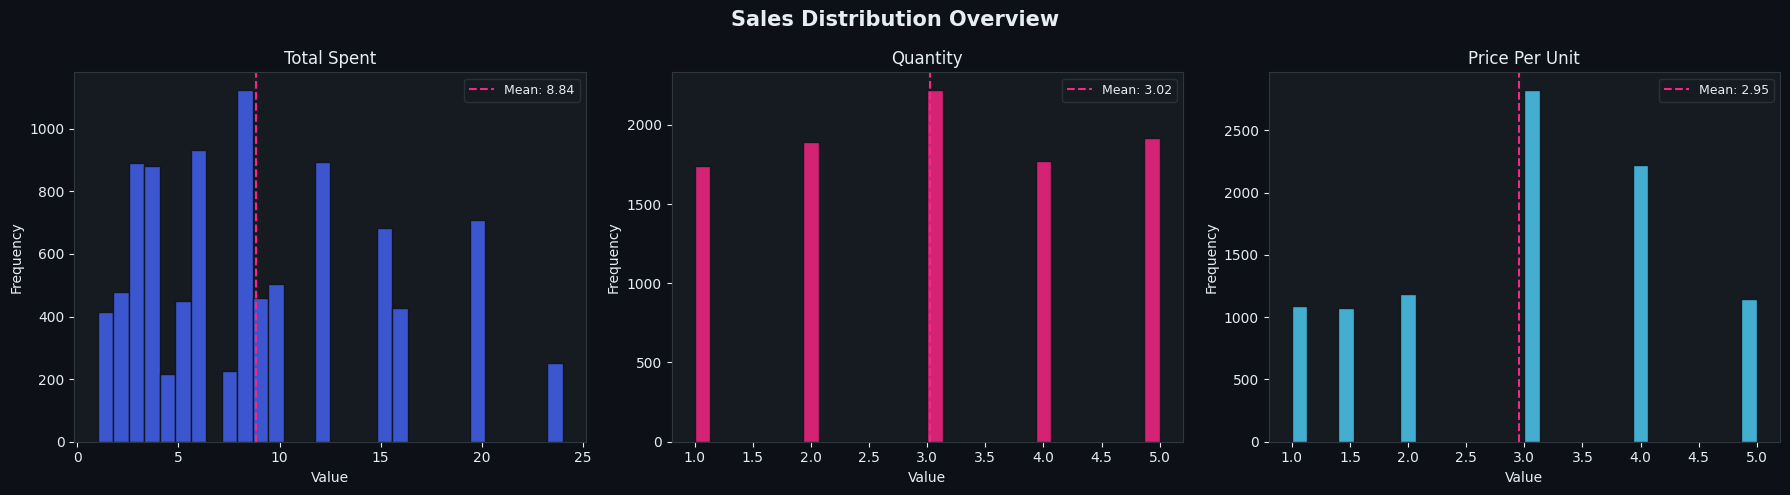

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle("Sales Distribution Overview", color=TEXT_CLR, fontsize=15, fontweight="bold")

for ax, col, clr in zip(axes, ["Total Spent", "Quantity", "Price Per Unit"], PALETTE):
    ax.set_facecolor(BG_CARD)
    ax.hist(df[col], bins=30, color=clr, alpha=0.85, edgecolor=BG_DARK)
    ax.axvline(df[col].mean(), color="#F72585", linestyle="--", linewidth=1.5,
               label=f"Mean: {df[col].mean():.2f}")
    ax.set_title(col, color=TEXT_CLR, fontsize=12)
    ax.set_xlabel("Value", color=TEXT_CLR)
    ax.set_ylabel("Frequency", color=TEXT_CLR)
    ax.legend(fontsize=9, labelcolor=TEXT_CLR, facecolor=BG_CARD, edgecolor=GRID_CLR)

plt.tight_layout()
plt.savefig("fig1_distributions.png", bbox_inches="tight", facecolor=BG_DARK, dpi=150)
plt.show()

5.3 Figure 2 — Sales by Category

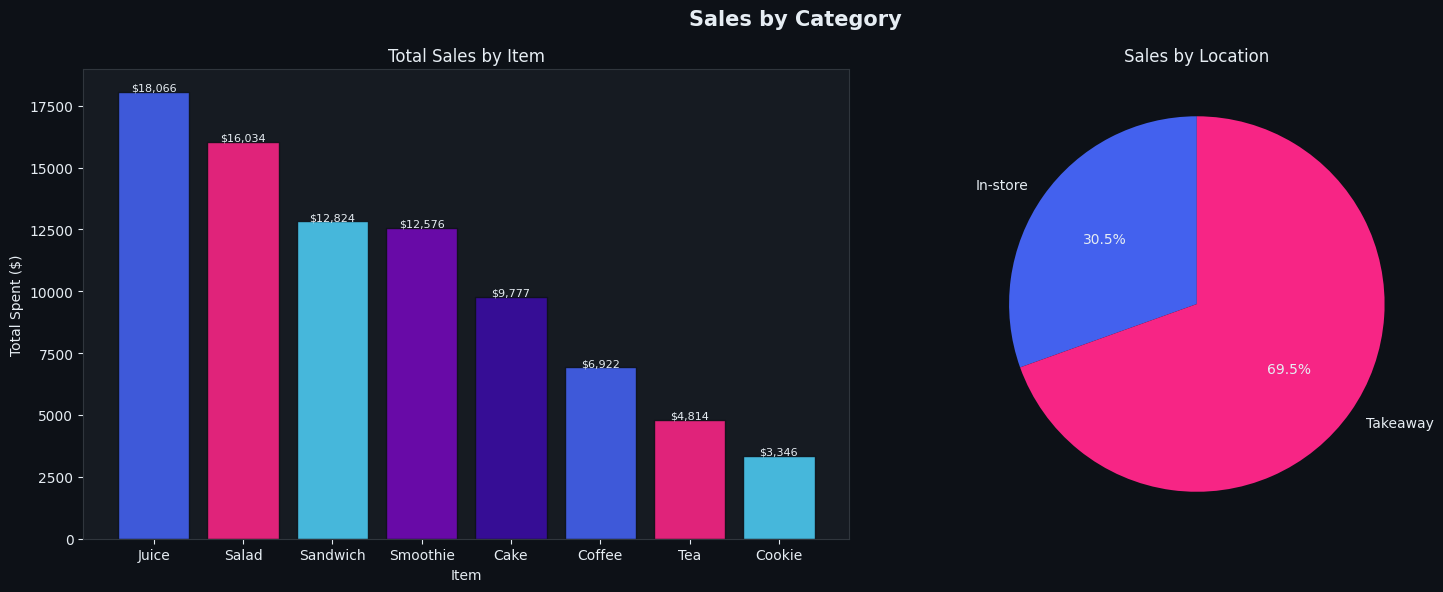

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle("Sales by Category", color=TEXT_CLR, fontsize=15, fontweight="bold")

# Sales by Item
ax1 = axes[0]
ax1.set_facecolor(BG_CARD)
item_sales = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
bars = ax1.bar(item_sales.index, item_sales.values,
               color=PALETTE[:len(item_sales)], alpha=0.9, edgecolor=BG_DARK)
ax1.set_title("Total Sales by Item", color=TEXT_CLR, fontsize=12)
ax1.set_xlabel("Item", color=TEXT_CLR)
ax1.set_ylabel("Total Spent ($)", color=TEXT_CLR)
for bar, val in zip(bars, item_sales.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"${val:,.0f}", ha="center", color=TEXT_CLR, fontsize=8)

# Sales by Location
ax2 = axes[1]
ax2.set_facecolor(BG_CARD)
loc_sales = df.groupby("Location")["Total Spent"].sum()
wedges, texts, autotexts = ax2.pie(loc_sales.values,
                                    labels=loc_sales.index,
                                    colors=PALETTE[:len(loc_sales)],
                                    autopct="%1.1f%%", startangle=90,
                                    textprops={"color": TEXT_CLR})
ax2.set_title("Sales by Location", color=TEXT_CLR, fontsize=12)

plt.tight_layout()
plt.savefig("fig2_categories.png", bbox_inches="tight", facecolor=BG_DARK, dpi=150)
plt.show()

5.4 Figure 3 — Correlation Matrix

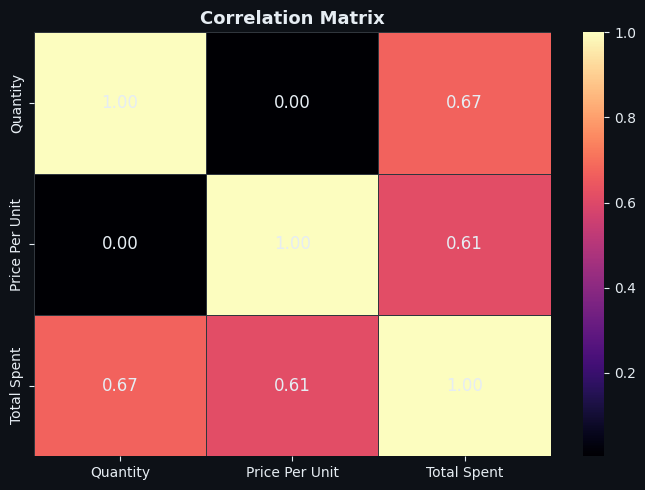

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_CARD)

corr = df[features].corr()
sns.heatmap(corr, ax=ax, cmap="magma", annot=True, fmt=".2f",
            linewidths=0.5, linecolor=GRID_CLR,
            annot_kws={"size": 12, "color": TEXT_CLR})
ax.set_title("Correlation Matrix", color=TEXT_CLR, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("fig3_correlation.png", bbox_inches="tight", facecolor=BG_DARK, dpi=150)
plt.show()

5.5 Figure 4 — PCA Analysis

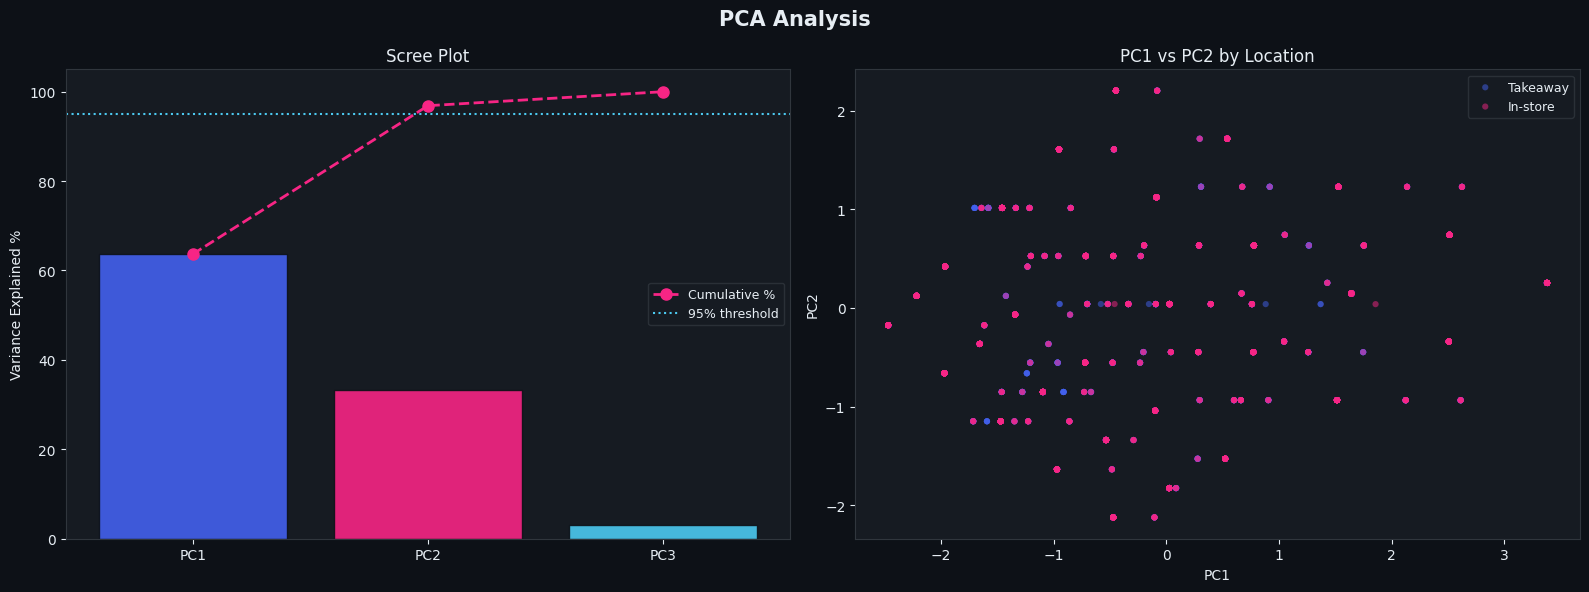

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle("PCA Analysis", color=TEXT_CLR, fontsize=15, fontweight="bold")

# Scree Plot
ax1 = axes[0]
ax1.set_facecolor(BG_CARD)
ax1.bar(["PC1", "PC2", "PC3"],
        pca_full.explained_variance_ratio_ * 100,
        color=PALETTE[:3], alpha=0.9, edgecolor=BG_DARK)
ax1.plot(["PC1", "PC2", "PC3"],
         np.cumsum(pca_full.explained_variance_ratio_) * 100,
         "o--", color="#F72585", linewidth=2, markersize=8, label="Cumulative %")
ax1.axhline(95, color="#4CC9F0", linestyle=":", linewidth=1.5, label="95% threshold")
ax1.set_title("Scree Plot", color=TEXT_CLR, fontsize=12)
ax1.set_ylabel("Variance Explained %", color=TEXT_CLR)
ax1.legend(fontsize=9, labelcolor=TEXT_CLR, facecolor=BG_CARD, edgecolor=GRID_CLR)

# PCA Scatter
ax2 = axes[1]
ax2.set_facecolor(BG_CARD)
locations = df_pca["Location"].unique()
pal = dict(zip(locations, PALETTE[:len(locations)]))
for loc in locations:
    mask = df_pca["Location"] == loc
    ax2.scatter(df_pca.loc[mask, "PC1"], df_pca.loc[mask, "PC2"],
                label=loc, alpha=0.5, color=pal[loc], s=20, edgecolors="none")
ax2.set_title("PC1 vs PC2 by Location", color=TEXT_CLR, fontsize=12)
ax2.set_xlabel("PC1", color=TEXT_CLR)
ax2.set_ylabel("PC2", color=TEXT_CLR)
ax2.legend(fontsize=9, labelcolor=TEXT_CLR, facecolor=BG_CARD, edgecolor=GRID_CLR)

plt.tight_layout()
plt.savefig("fig4_pca.png", bbox_inches="tight", facecolor=BG_DARK, dpi=150)
plt.show()

Step 6 — Save Outputs

6.1 Export Cleaned Data



In [18]:
df.to_csv("cleaned_cafe_sales.csv", index=False, encoding="utf-8-sig")
df_pca.to_csv("pca_cafe_sales.csv", index=False, encoding="utf-8-sig")

print("Files saved successfully!")
print(f"cleaned_cafe_sales.csv — shape: {df.shape}")
print(f"pca_cafe_sales.csv     — shape: {df_pca.shape}")

Files saved successfully!
cleaned_cafe_sales.csv — shape: (9540, 8)
pca_cafe_sales.csv     — shape: (9540, 5)


6.2 Package and Download

In [19]:
from google.colab import files

files.download("cleaned_cafe_sales.csv")
files.download("pca_cafe_sales.csv")
files.download("fig1_distributions.png")
files.download("fig2_categories.png")
files.download("fig3_correlation.png")
files.download("fig4_pca.png")

print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
